In [1]:
import pandas as pd

In [2]:
# Load the required files
vote_sessions = pd.read_csv("../data/vote_sessions_full.csv", usecols=["id", "data", "aprovacao", "propositionID", "siglaOrgao", "year", "author_type", "num_authors", "theme", "legislatura", "Governo", "Oposição", "GOV."])
content_cluster = pd.read_csv("../Content/prop_content.csv", usecols=["id", "content"])
authors_pop = pd.read_csv("../Author's Popularity/author_popularity.csv", usecols=["idVotacao", "popularity"])
authors_comm = pd.read_csv("../Author's Group/authors_community_dataset_one_year_window.csv", usecols=["id", "author_prev_community", "prev_community_0_size", "prev_community_1_size", "prev_community_2_size"])

# Merge vote_sessions with content_cluster
merged_df = vote_sessions.merge(
    content_cluster, left_on="id", right_on="id", how="left"
)

# Merge with authors_pop (id in vote_sessions matches idVotacao in authors_pop)
merged_df = merged_df.merge(
    authors_pop, left_on="id", right_on="idVotacao", how="left"
)

# Merge with authors_comm (id in vote_sessions matches id in authors_comm)
merged_df = merged_df.merge(
    authors_comm, left_on="id", right_on="id", how="left"
)

# Remove duplicated columns: "propositionID", "idVotacao"
merged_df = merged_df.drop(columns=["propositionID", "idVotacao"])

# Keep only unique values of the 'id' column
merged_df = merged_df.drop_duplicates(subset=["id"], keep="first")

In [3]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9260 entries, 0 to 2099179
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     9260 non-null   object 
 1   data                   9260 non-null   object 
 2   siglaOrgao             9260 non-null   object 
 3   aprovacao              8914 non-null   float64
 4   year                   9260 non-null   int64  
 5   GOV.                   9260 non-null   int64  
 6   Governo                9260 non-null   int64  
 7   Oposição               9260 non-null   int64  
 8   author_type            9260 non-null   object 
 9   num_authors            9260 non-null   int64  
 10  theme                  9252 non-null   object 
 11  legislatura            9260 non-null   int64  
 12  content                9260 non-null   object 
 13  popularity             1990 non-null   float64
 14  author_prev_community  4130 non-null   float64
 15  p

In [4]:
print("Valores únicos da coluna 'GOV.':", merged_df['GOV.'].unique())
print("Valores únicos da coluna 'Governo':", merged_df['Governo'].unique())


Valores únicos da coluna 'GOV.': [ 0  1 -1]
Valores únicos da coluna 'Governo': [ 0  1 -1]


In [5]:
# Calcula a porcentagem de linhas em que 'GOV.' diverge de 'Governo'
total_linhas = len(merged_df)
divergentes_mask = merged_df['GOV.'] != merged_df['Governo']
divergentes = divergentes_mask.sum()
percentual_divergentes = (divergentes / total_linhas) * 100
print(f"Percentual de linhas em que 'GOV.' diverge de 'Governo': {percentual_divergentes:.2f}%")

# Mostra alguns exemplos dessas linhas que divergem
exemplos_divergentes = merged_df.loc[divergentes_mask, ['id', 'GOV.', 'Governo']].head(10)
print("Exemplos de linhas divergentes entre 'GOV.' e 'Governo':")
print(exemplos_divergentes)


Percentual de linhas em que 'GOV.' diverge de 'Governo': 16.59%
Exemplos de linhas divergentes entre 'GOV.' e 'Governo':
             id  GOV.  Governo
101   115155-58     1        0
368  125572-116     1        0
492   145211-10     1        0
535    32147-56     1        0
557    150930-5     1        0
558    151030-5     1        0
796    252929-5     1        0
828   126541-68     1        0
837   140174-83    -1        0
938   109175-70     1        0


In [6]:
def resolve_gov_orientation(row):
    if row['GOV.'] == row['Governo']:
        return row['GOV.']
    else:
        # Se discordam, retorna o valor diferente de zero (1 ou -1)
        if row['GOV.'] != 0:
            return row['GOV.']
        else:
            return row['Governo']

merged_df['gov_orientation'] = merged_df.apply(resolve_gov_orientation, axis=1)


In [7]:
# Convert the 'data' column to datetime
merged_df['data'] = pd.to_datetime(merged_df['data'], errors='coerce')

# Convert the 'aprovacao' column to int
merged_df['aprovacao'] = pd.to_numeric(merged_df['aprovacao'], errors='coerce').astype('Int64')

# Convert the community size columns to int
for col in ['prev_community_0_size', 'prev_community_1_size', 'prev_community_2_size']:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce').astype('Int64')


In [8]:
# Truncate 'num_authors' values at 10, keeping values <=10 as is
merged_df['num_authors_trunc'] = merged_df['num_authors'].apply(lambda x: x if x <= 10 else 10)

# Create a new boolean column to tag propositions with more than 10 authors
merged_df['has_more_than_10_authors'] = merged_df['num_authors'] > 10



In [9]:
merged_df['popularity'] = merged_df['popularity'].fillna(0)

# Substituir valores N/A na coluna 'author_prev_community' por -1 
# (valor fora do intervalo 0-2 para indicar "comunidade desconhecida")
merged_df['author_prev_community'] = merged_df['author_prev_community'].fillna(-1)



In [10]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9260 entries, 0 to 2099179
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   id                        9260 non-null   object        
 1   data                      9260 non-null   datetime64[ns]
 2   siglaOrgao                9260 non-null   object        
 3   aprovacao                 8914 non-null   Int64         
 4   year                      9260 non-null   int64         
 5   GOV.                      9260 non-null   int64         
 6   Governo                   9260 non-null   int64         
 7   Oposição                  9260 non-null   int64         
 8   author_type               9260 non-null   object        
 9   num_authors               9260 non-null   int64         
 10  theme                     9252 non-null   object        
 11  legislatura               9260 non-null   int64         
 12  content          

In [11]:
merged_df = merged_df.dropna(subset=['aprovacao'])

In [12]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8914 entries, 0 to 2099179
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   id                        8914 non-null   object        
 1   data                      8914 non-null   datetime64[ns]
 2   siglaOrgao                8914 non-null   object        
 3   aprovacao                 8914 non-null   Int64         
 4   year                      8914 non-null   int64         
 5   GOV.                      8914 non-null   int64         
 6   Governo                   8914 non-null   int64         
 7   Oposição                  8914 non-null   int64         
 8   author_type               8914 non-null   object        
 9   num_authors               8914 non-null   int64         
 10  theme                     8906 non-null   object        
 11  legislatura               8914 non-null   int64         
 12  content          

In [13]:
# Mostrar a contagem de valores nulos em cada coluna de merged_df
print("Valores nulos por coluna em merged_df:")
print(merged_df.isnull().sum())


Valores nulos por coluna em merged_df:
id                            0
data                          0
siglaOrgao                    0
aprovacao                     0
year                          0
GOV.                          0
Governo                       0
Oposição                      0
author_type                   0
num_authors                   0
theme                         8
legislatura                   0
content                       0
popularity                    0
author_prev_community         0
prev_community_0_size       287
prev_community_1_size       287
prev_community_2_size         0
gov_orientation               0
num_authors_trunc             0
has_more_than_10_authors      0
dtype: int64


In [14]:
# Preencher valores nulos na coluna 'theme' com "Not defined"
merged_df['theme'] = merged_df['theme'].fillna("Not defined")

# Preencher valores nulos nas colunas 'prev_community_0_size' e 'prev_community_1_size' com zero
merged_df['prev_community_0_size'] = merged_df['prev_community_0_size'].fillna(0)
merged_df['prev_community_1_size'] = merged_df['prev_community_1_size'].fillna(0)


In [15]:
print("Valores únicos da coluna 'siglaOrgao':")
print(merged_df['siglaOrgao'].unique())


Valores únicos da coluna 'siglaOrgao':
['PLEN']


In [16]:
print(merged_df['aprovacao'].value_counts())


1    7084
0    1830
Name: aprovacao, dtype: Int64


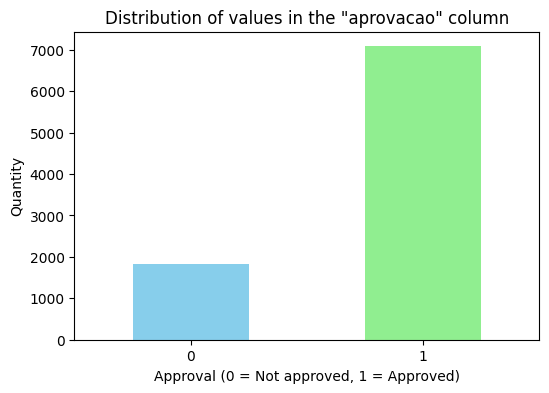

In [17]:
import matplotlib.pyplot as plt

# Count the values 0 and 1 in the 'aprovacao' column
approval_counts = merged_df['aprovacao'].value_counts().sort_index()

# Create the bar chart
plt.figure(figsize=(6,4))
approval_counts.plot(kind='bar', color=['skyblue', 'lightgreen'])
plt.title('Distribution of values in the "aprovacao" column')
plt.xlabel('Approval (0 = Not approved, 1 = Approved)')
plt.ylabel('Quantity')
plt.xticks([0,1], ['0', '1'], rotation=0)
plt.show()


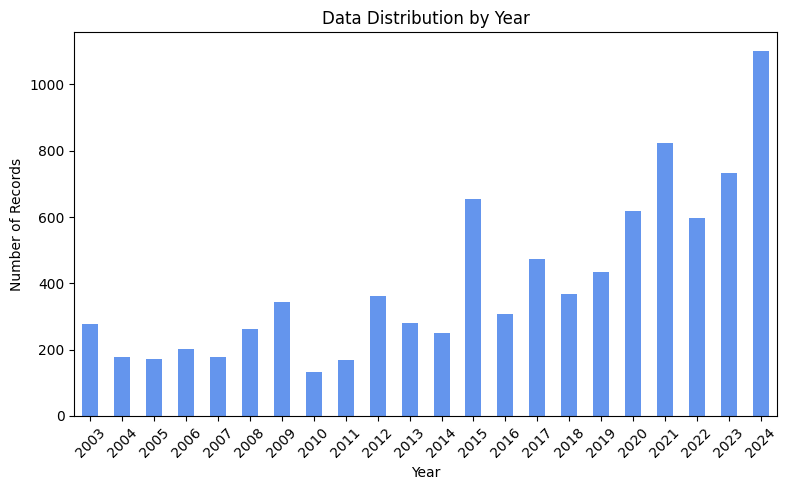

In [18]:
import matplotlib.pyplot as plt

# Count the number of occurrences for each year
year_counts = merged_df['year'].value_counts().sort_index()

# Create the bar chart
plt.figure(figsize=(8,5))
year_counts.plot(kind='bar', color='cornflowerblue')
plt.title('Data Distribution by Year')
plt.xlabel('Year')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


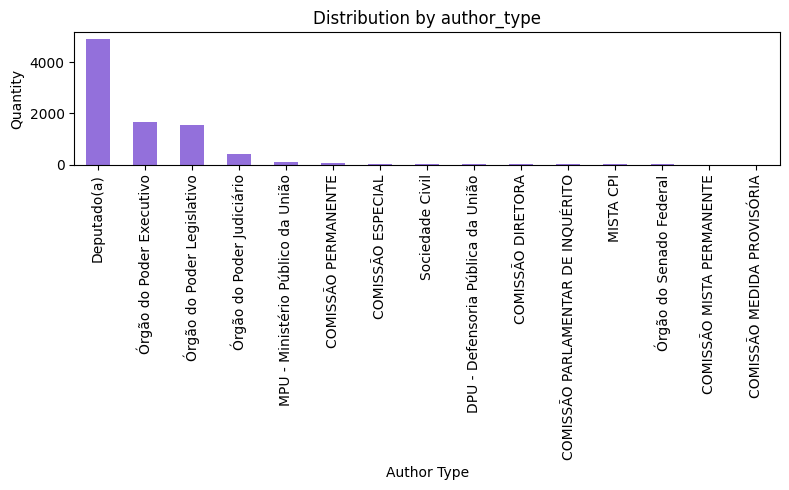

In [19]:
import matplotlib.pyplot as plt

# Check if the 'author_type' column exists
if 'author_type' in merged_df.columns:
    # Order from most to least
    author_type_counts = merged_df['author_type'].value_counts().sort_values(ascending=False)
    plt.figure(figsize=(8,5))
    author_type_counts.plot(kind='bar', color='mediumpurple')
    plt.title('Distribution by author_type')
    plt.xlabel('Author Type')
    plt.ylabel('Quantity')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
else:
    print("The 'author_type' column is not present in the DataFrame.")


In [20]:
# Selecionar as features e o target para o novo dataset
features = [
    'content',
    'popularity',
    'author_prev_community',
    'prev_community_0_size',
    'prev_community_1_size',
    'prev_community_2_size',
    'gov_orientation',
    'num_authors_trunc',
    'has_more_than_10_authors'
]
target = 'aprovacao'

# Criar o novo DataFrame apenas com as features e o target
dataset_features_target = merged_df[features + [target]].copy()


Splitting X and y while preserving temporal order...
Performing temporal split (80% train, 20% test)...
Preparing documents for Doc2Vec (train only)...
Training Doc2Vec model...
Inferring Doc2Vec vectors for train set...
Clustering train vectors with KMeans...
Adding cluster column to X_train...
Inferring Doc2Vec vectors for test set...
Predicting clusters for test set...
Updating final feature list...
Normalizing numeric features...
Selecting final features for the model...
Defining F1 scorer for class 'Rejected' (0)...
Starting GridSearch for XGBoost...
GridSearchCV will run 672 parameter combinations x 3 folds = 2016 fits.


e:\Anaconda\envs\votes_prediction\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


GridSearch XGBoost Progress:   0%|          | 0/2016 [00:00<?, ?it/s]

Fitting 3 folds for each of 672 candidates, totalling 2016 fits


e:\Anaconda\envs\votes_prediction\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


XGBoost (GridSearch) best F1_reprovada: 0.5305 with params: {'colsample_bytree': 0.8, 'gamma': 1, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'scale_pos_weight': 1, 'subsample': 0.8}
Best F1_reprovada = 0.702 at threshold=0.27


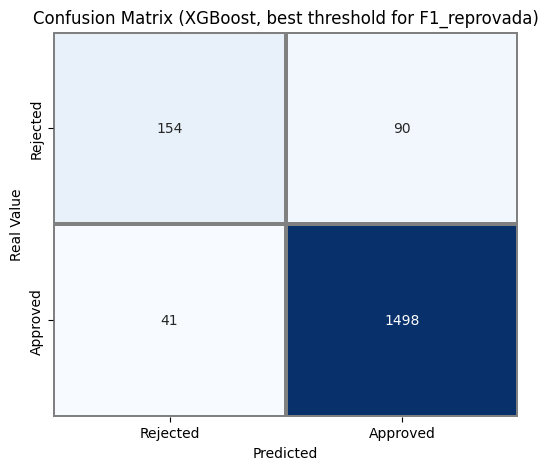


Confusion matrix (XGBoost, optimal threshold for F1_reprovada):
[[ 154   90]
 [  41 1498]]
              precision    recall  f1-score   support

    Rejected      0.790     0.631     0.702       244
    Approved      0.943     0.973     0.958      1539

    accuracy                          0.927      1783
   macro avg      0.867     0.802     0.830      1783
weighted avg      0.922     0.927     0.923      1783

XGBoost AUROC (test): 0.8836
Adding XGBoost predictions to merged_df...
Using X_test index to fetch 'id' from merged_df.
Adjusting prediction Series index to match real 'id' values in merged_df.
Merging predictions into merged_df...
Predictions added to merged_df.
Calculating XGBoost feature importances...

Feature importances (XGBoost):
                    feature  importance
5           gov_orientation    0.445525
7  has_more_than_10_authors    0.241813
6         num_authors_trunc    0.098580
0                popularity    0.055321
8           content_cluster    0.049686
1

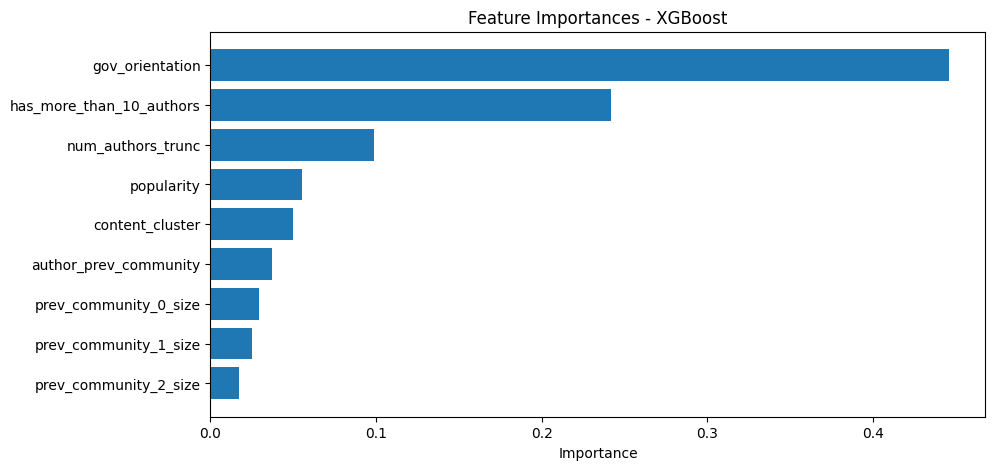

In [21]:
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.cluster import KMeans
from sklearn.metrics import (
    precision_recall_curve, f1_score, classification_report, confusion_matrix, make_scorer, roc_auc_score
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import numpy as np
import pandas as pd

print("Splitting X and y while preserving temporal order...")
X = dataset_features_target[features]
y = dataset_features_target[target]

# Identify numeric features for normalization
numeric_features = [
    'popularity',
    'author_prev_community',
    'prev_community_0_size',
    'prev_community_1_size',
    'prev_community_2_size',
]

# Identify categorical/textual features
categorical_features = [f for f in features if f not in numeric_features]

print("Performing temporal split (80% train, 20% test)...")
split_idx = int(0.8 * len(X))
X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

print("Preparing documents for Doc2Vec (train only)...")
documents = [TaggedDocument(str(text).split(), [i]) for i, text in enumerate(X_train['content'])]

print("Training Doc2Vec model...")
doc2vec_model = Doc2Vec(vector_size=64, min_count=1, epochs=40, workers=4, seed=42)
doc2vec_model.build_vocab(documents)
doc2vec_model.train(documents, total_examples=doc2vec_model.corpus_count, epochs=doc2vec_model.epochs)

print("Inferring Doc2Vec vectors for train set...")
X_train_docvec = np.array([doc2vec_model.infer_vector(str(text).split()) for text in X_train['content']])

print("Clustering train vectors with KMeans...")
n_clusters = 8  # Adjust this value as needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
X_train_clusters = kmeans.fit_predict(X_train_docvec)

print("Adding cluster column to X_train...")
X_train_with_cluster = X_train.copy()
X_train_with_cluster['content_cluster'] = X_train_clusters

print("Inferring Doc2Vec vectors for test set...")
X_test_docvec = np.array([doc2vec_model.infer_vector(str(text).split()) for text in X_test['content']])
print("Predicting clusters for test set...")
X_test_clusters = kmeans.predict(X_test_docvec)
X_test_with_cluster = X_test.copy()
X_test_with_cluster['content_cluster'] = X_test_clusters

print("Updating final feature list...")
final_features = [f for f in features if f != 'content'] + ['content_cluster']

print("Normalizing numeric features...")
scaler = StandardScaler()
X_train_scaled = X_train_with_cluster.copy()
X_test_scaled = X_test_with_cluster.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train_with_cluster[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test_with_cluster[numeric_features])

print("Selecting final features for the model...")
X_train_model = X_train_scaled[final_features]
X_test_model = X_test_scaled[final_features]

print("Defining F1 scorer for class 'Rejected' (0)...")
f1_reprovada_scorer = make_scorer(f1_score, pos_label=0, average='binary')

# --------------- XGBoost ONLY ---------------
print("Starting GridSearch for XGBoost...")

from sklearn.model_selection import ParameterGrid
import time

# Try to improve recall for class 0 by using more aggressive class weighting and additional hyperparameters
neg, pos = y_train.value_counts()   # neg = rejected, pos = approved
# Add more aggressive scale_pos_weight values
scale_pos_weights = [1, neg / pos, 2*neg / pos, 3*neg / pos, 5*neg / pos, 10*neg / pos, 20*neg / pos]
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [ 0.05, 0.1],
    'scale_pos_weight': scale_pos_weights,
    'subsample': [0.8],
    'colsample_bytree': [0.6, 0.8],
    'gamma': [0, 1],
    'min_child_weight': [1, 5]
}
total_param_combinations = len(list(ParameterGrid(xgb_param_grid)))
cv_folds = 3
total_fits = total_param_combinations * cv_folds

print(f"GridSearchCV will run {total_param_combinations} parameter combinations x {cv_folds} folds = {total_fits} fits.")

from tqdm.notebook import tqdm

class VerboseGridSearchCV(GridSearchCV):
    def fit(self, X, y=None, **fit_params):
        self._tqdm_bar = tqdm(total=total_fits, desc="GridSearch XGBoost Progress", leave=True)
        from sklearn.model_selection._validation import _fit_and_score as orig_fit_and_score
        def _fit_and_score(*args, **kwargs):
            result = orig_fit_and_score(*args, **kwargs)
            self._tqdm_bar.update(1)
            return result
        import sklearn.model_selection._validation
        old_func = sklearn.model_selection._validation._fit_and_score
        sklearn.model_selection._validation._fit_and_score = _fit_and_score
        try:
            result = super().fit(X, y, **fit_params)
        finally:
            sklearn.model_selection._validation._fit_and_score = old_func
            self._tqdm_bar.close()
        return result

xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', tree_method='hist')

# Use the original y (not inverted) and optimize for F1 of class 0 directly
xgb_grid = VerboseGridSearchCV(
    xgb,
    xgb_param_grid,
    scoring=f1_reprovada_scorer,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train_model, y_train)
print(f"XGBoost (GridSearch) best F1_reprovada: {xgb_grid.best_score_:.4f} with params: {xgb_grid.best_params_}")
xgb_best = xgb_grid.best_estimator_

# Get predicted probabilities for class 0
y_proba_0 = xgb_best.predict_proba(X_test_model)[:, 0]
prec_0, rec_0, thresh_0 = precision_recall_curve(y_test, y_proba_0, pos_label=0)
f1_0 = 2 * (prec_0 * rec_0) / (prec_0 + rec_0 + 1e-8)
best_idx_0 = f1_0.argmax()
best_thresh_0 = thresh_0[best_idx_0] if best_idx_0 < len(thresh_0) else 0.5
print(f"Best F1_reprovada = {f1_0[best_idx_0]:.3f} at threshold={best_thresh_0:.2f}")

# Predict using the best threshold for class 0
y_pred_xgb_f1_0 = (y_proba_0 >= best_thresh_0).astype(int) * 0 + (y_proba_0 < best_thresh_0).astype(int) * 1

# --- Visual Confusion Matrix and Metrics Table (like @file_context_0) ---
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_xgb_f1_0)
cm_labels = ["Rejected", "Approved"]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=cm_labels, yticklabels=cm_labels, cbar=False, linewidths=1.5, linecolor='gray')
plt.xlabel("Predicted")
plt.ylabel("Real Value")
plt.title("Confusion Matrix (XGBoost, best threshold for F1_reprovada)")
plt.show()

print("\nConfusion matrix (XGBoost, optimal threshold for F1_reprovada):")
print(cm)
print(classification_report(y_test, y_pred_xgb_f1_0, digits=3, target_names=["Rejected","Approved"]))

xgb_auroc = roc_auc_score(y_test, xgb_best.predict_proba(X_test_model)[:, 1])
print(f"XGBoost AUROC (test): {xgb_auroc:.4f}")



# ----------------- ADD XGBOOST PREDICTIONS TO merged_df -----------------
print("Adding XGBoost predictions to merged_df...")

# 1. Get the indices/ids of the test samples
if 'id' in X_test.columns and 'id' in merged_df.columns:
    print("Using 'id' column from X_test and merged_df for alignment.")
    test_ids = X_test['id'].values
elif 'id' in merged_df.columns:
    print("Using X_test index to fetch 'id' from merged_df.")
    test_ids = X_test.index
else:
    print("No 'id' column found, using index.")
    test_ids = X_test.index

# 2. Get model predictions for the test set (using optimal threshold for F1_reprovada)
y_pred_xgb_final = y_pred_xgb_f1_0

# 3. Create a Series with results, indexed by ids
pred_series = pd.Series(y_pred_xgb_final, index=test_ids, name='aprovacao_predita_xgb')

# 4. Add prediction column to merged_df
if 'id' in merged_df.columns:
    if 'id' not in X_test.columns:
        print("Adjusting prediction Series index to match real 'id' values in merged_df.")
        test_ids_real = merged_df.loc[test_ids, 'id']
        pred_series.index = test_ids_real
    if 'aprovacao_predita_xgb' in merged_df.columns:
        print("Removing existing 'aprovacao_predita_xgb' column from merged_df to avoid merge conflict.")
        merged_df = merged_df.drop(columns=['aprovacao_predita_xgb'])
    print("Merging predictions into merged_df...")
    merged_df = merged_df.merge(pred_series, left_on='id', right_index=True, how='left')
else:
    print("Adding 'aprovacao_predita_xgb' column directly to merged_df (no 'id' column).")
    merged_df['aprovacao_predita_xgb'] = pred_series

print("Predictions added to merged_df.")

# ----------------- XGBOOST FEATURE IMPORTANCE -----------------
import matplotlib.pyplot as plt

print("Calculating XGBoost feature importances...")
importances = xgb_best.feature_importances_
feature_names = X_train_model.columns

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

print("\nFeature importances (XGBoost):")
print(importance_df)

plt.figure(figsize=(10,5))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance')
plt.title('Feature Importances - XGBoost')
plt.gca().invert_yaxis()
plt.show()


In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# Baseline 1: Predict ALL propositions as "approved" (1)
y_pred_all_approved = pd.Series(1, index=y_test.index)

precision_baseline = precision_score(y_test, y_pred_all_approved, pos_label=1)
recall_baseline = recall_score(y_test, y_pred_all_approved, pos_label=1)
f1_baseline = f1_score(y_test, y_pred_all_approved, pos_label=1)
try:
    auroc_baseline = roc_auc_score(y_test, y_pred_all_approved)
except ValueError:
    auroc_baseline = float('nan')

print("=== Baseline: Predict ALL Approved ===")
print(f"Precision: {precision_baseline:.3f}")
print(f"Recall:    {recall_baseline:.3f}")
print(f"F1 Score:  {f1_baseline:.3f}")
print(f"AUROC:     {auroc_baseline:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_all_approved, digits=3, target_names=["Rejected","Approved"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_all_approved))
print("\n")

# Baseline 2: Random prediction (equal probability for approved/rejected)
import numpy as np

np.random.seed(42)
y_pred_random = pd.Series(np.random.choice([0, 1], size=len(y_test)), index=y_test.index)

precision_random = precision_score(y_test, y_pred_random, pos_label=1)
recall_random = recall_score(y_test, y_pred_random, pos_label=1)
f1_random = f1_score(y_test, y_pred_random, pos_label=1)
try:
    auroc_random = roc_auc_score(y_test, y_pred_random)
except ValueError:
    auroc_random = float('nan')

print("=== Baseline: Random Prediction (50/50) ===")
print(f"Precision: {precision_random:.3f}")
print(f"Recall:    {recall_random:.3f}")
print(f"F1 Score:  {f1_random:.3f}")
print(f"AUROC:     {auroc_random:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_random, digits=3, target_names=["Rejected","Approved"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_random))
print("\n")

# Baseline 3: Weighted random prediction (match class distribution in y_train)
# Calculate proportion of approved (1) and rejected (0) in y_train
p_approved = y_train.mean()
p_rejected = 1 - p_approved

y_pred_weighted_random = pd.Series(
    np.random.choice([0, 1], size=len(y_test), p=[p_rejected, p_approved]),
    index=y_test.index
)

precision_weighted = precision_score(y_test, y_pred_weighted_random, pos_label=1)
recall_weighted = recall_score(y_test, y_pred_weighted_random, pos_label=1)
f1_weighted = f1_score(y_test, y_pred_weighted_random, pos_label=1)
try:
    auroc_weighted = roc_auc_score(y_test, y_pred_weighted_random)
except ValueError:
    auroc_weighted = float('nan')

print("=== Baseline: Weighted Random Prediction (train class distribution) ===")
print(f"Proportion Approved in Train: {p_approved:.3f}")
print(f"Precision: {precision_weighted:.3f}")
print(f"Recall:    {recall_weighted:.3f}")
print(f"F1 Score:  {f1_weighted:.3f}")
print(f"AUROC:     {auroc_weighted:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_weighted_random, digits=3, target_names=["Rejected","Approved"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_weighted_random))
print("\n")


=== Baseline: Predict ALL Approved ===
Precision: 0.863
Recall:    1.000
F1 Score:  0.927
AUROC:     0.500

Classification Report:
              precision    recall  f1-score   support

    Rejected      0.000     0.000     0.000       244
    Approved      0.863     1.000     0.927      1539

    accuracy                          0.863      1783
   macro avg      0.432     0.500     0.463      1783
weighted avg      0.745     0.863     0.800      1783

Confusion Matrix:
[[   0  244]
 [   0 1539]]


=== Baseline: Random Prediction (50/50) ===
Precision: 0.881
Recall:    0.504
F1 Score:  0.641
AUROC:     0.537

Classification Report:
              precision    recall  f1-score   support

    Rejected      0.154     0.570     0.242       244
    Approved      0.881     0.504     0.641      1539

    accuracy                          0.513      1783
   macro avg      0.517     0.537     0.442      1783
weighted avg      0.781     0.513     0.586      1783

Confusion Matrix:
[[139 105]
 [7

e:\Anaconda\envs\votes_prediction\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
e:\Anaconda\envs\votes_prediction\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
e:\Anaconda\envs\votes_prediction\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [22]:
merged_df_preditos = merged_df[merged_df['aprovacao_predita_xgb'].notna()]


In [23]:
merged_df_preditos

,id,data,siglaOrgao,aprovacao,year,GOV.,Governo,Oposição,author_type,num_authors,...,content,popularity,author_prev_community,prev_community_0_size,prev_community_1_size,prev_community_2_size,gov_orientation,num_authors_trunc,has_more_than_10_authors,aprovacao_predita_xgb
1361563,2301683-48,2023-03-22,PLEN,1,2023,0,0,0,Deputado(a),5,...,Votação da Redação Final. Parecer às Emendas d...,0.000000,1.0,441,155,0,0,5,False,1.0
1361564,946514-132,2023-03-22,PLEN,1,2023,0,0,0,Deputado(a),10,...,Votação da Redação Final. Apresentação da Emen...,0.000000,1.0,441,155,0,0,10,False,1.0
1361565,2351655-7,2023-03-22,PLEN,1,2023,0,0,0,Deputado(a),14,...,Acrescenta parágrafo único ao art. 87 e § 3º a...,0.000000,-1.0,441,155,0,0,10,True,1.0
1361569,2352308-8,2023-03-22,PLEN,1,2023,0,0,0,Deputado(a),10,...,"Institui a ""Semana Nacional do Uso Consciente ...",0.000000,1.0,441,155,0,0,10,False,1.0
1361570,2352400-8,2023-03-22,PLEN,1,2023,0,0,0,Deputado(a),4,...,"Altera a Lei nº 13.146, de 2015, para prever o...",0.000000,0.0,441,155,0,0,4,False,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2090423,2473375-59,2024-12-19,PLEN,1,2024,0,1,-1,Deputado(a),252,...,Votação em turno único. Parecer às Emendas de ...,0.517787,0.0,392,198,0,1,10,True,1.0
2096255,2473375-80,2024-12-19,PLEN,1,2024,0,0,0,Deputado(a),252,...,Votação da Redação Final. Parecer às Emendas d...,0.000000,0.0,392,198,0,0,10,True,1.0
2099171,2460010-35,2024-12-19,PLEN,0,2024,0,-1,1,Deputado(a),6,...,"Altera a Lei nº 14.467, de 16 de novembro de 2...",0.471170,0.0,392,198,0,-1,6,False,0.0
2099175,2460010-43,2024-12-19,PLEN,1,2024,0,1,-1,Deputado(a),6,...,Votação em turno único. Parecer proferido em P...,0.458564,0.0,392,198,0,1,6,False,1.0


In [24]:
# Cria uma coluna para identificar o tipo de predição (VP, VN, FP, FN)
# Considerando que 'aprovacao' é o valor real e 'aprovacao_predita_xgb' é a previsão

def classificar_predicao(row):
    real = row['aprovacao']
    pred = row['aprovacao_predita_xgb']
    if real == 1 and pred == 1:
        return 'Verdadeiro Positivo'
    elif real == 0 and pred == 0:
        return 'Verdadeiro Negativo'
    elif real == 0 and pred == 1:
        return 'Falso Positivo'
    elif real == 1 and pred == 0:
        return 'Falso Negativo'
    else:
        return 'Outro'

merged_df_preditos['tipo_predicao'] = merged_df_preditos.apply(classificar_predicao, axis=1)

# Agora, crie uma tabela (DataFrame) com cada grupo
tabela_predicoes = merged_df_preditos.groupby('tipo_predicao').size().reset_index(name='quantidade')
tabela_predicoes


C:\Users\Pedro Natanael\AppData\Local\Temp\ipykernel_5744\219703434.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_df_preditos['tipo_predicao'] = merged_df_preditos.apply(classificar_predicao, axis=1)


,tipo_predicao,quantidade
0,Falso Negativo,41
1,Falso Positivo,90
2,Verdadeiro Negativo,154
3,Verdadeiro Positivo,1498


In [25]:
# Agrupa por 'theme' e 'tipo_predicao' e conta a quantidade de cada combinação
tabela_tema_predicao = merged_df_preditos.groupby(['theme', 'tipo_predicao']).size().reset_index(name='quantidade')

# Pivot para facilitar visualização: linhas = tema, colunas = tipo_predicao
tabela_tema_predicao_pivot = tabela_tema_predicao.pivot(index='theme', columns='tipo_predicao', values='quantidade').fillna(0).astype(int)

# Garante que todas as colunas estejam presentes
for col in ['Falso Negativo', 'Falso Positivo', 'Verdadeiro Positivo', 'Verdadeiro Negativo']:
    if col not in tabela_tema_predicao_pivot.columns:
        tabela_tema_predicao_pivot[col] = 0

# Calcula o % de erro para cada tema
tabela_tema_predicao_pivot['percentual_erro'] = (
    (tabela_tema_predicao_pivot['Falso Negativo'] + tabela_tema_predicao_pivot['Falso Positivo']) /
    (tabela_tema_predicao_pivot['Falso Negativo'] + tabela_tema_predicao_pivot['Falso Positivo'] +
     tabela_tema_predicao_pivot['Verdadeiro Positivo'] + tabela_tema_predicao_pivot['Verdadeiro Negativo'])
).fillna(0)

# Ranqueia do menor para o maior percentual de erro
tabela_tema_predicao_rank = tabela_tema_predicao_pivot.sort_values('percentual_erro', ascending=True)

# Exibe a tabela ranqueada com os valores de VP, VN, FP, FN e percentual de erro
tabela_tema_predicao_rank[['percentual_erro', 'Verdadeiro Positivo', 'Verdadeiro Negativo', 'Falso Positivo', 'Falso Negativo']]


tipo_predicao,percentual_erro,Verdadeiro Positivo,Verdadeiro Negativo,Falso Positivo,Falso Negativo
theme,,,,,
Previdência e Assistência Social,0.000000,17,0,0,0
"Indústria, Comércio e Serviços",0.000000,9,0,0,0
Homenagens e Datas Comemorativas,0.000000,25,0,0,0
Direito e Justiça,0.000000,5,1,0,0
Esporte e Lazer,0.000000,16,0,0,0
Turismo,0.000000,2,0,0,0
Saúde,0.016529,114,5,1,1
Defesa e Segurança,0.020619,95,0,1,1
"Viação, Transporte e Mobilidade",0.024390,37,3,1,0


In [26]:
# Agrupa por 'theme' e 'tipo_predicao' e conta a quantidade de cada combinação
tabela_tema_predicao = merged_df_preditos.groupby(['legislatura', 'tipo_predicao']).size().reset_index(name='quantidade')

# Pivot para facilitar visualização: linhas = tema, colunas = tipo_predicao
tabela_tema_predicao_pivot = tabela_tema_predicao.pivot(index='legislatura', columns='tipo_predicao', values='quantidade').fillna(0).astype(int)

# Garante que todas as colunas estejam presentes
for col in ['Falso Negativo', 'Falso Positivo', 'Verdadeiro Positivo', 'Verdadeiro Negativo']:
    if col not in tabela_tema_predicao_pivot.columns:
        tabela_tema_predicao_pivot[col] = 0

# Calcula o % de erro para cada tema
tabela_tema_predicao_pivot['percentual_erro'] = (
    (tabela_tema_predicao_pivot['Falso Negativo'] + tabela_tema_predicao_pivot['Falso Positivo']) /
    (tabela_tema_predicao_pivot['Falso Negativo'] + tabela_tema_predicao_pivot['Falso Positivo'] +
     tabela_tema_predicao_pivot['Verdadeiro Positivo'] + tabela_tema_predicao_pivot['Verdadeiro Negativo'])
).fillna(0)

# Ranqueia do menor para o maior percentual de erro
tabela_tema_predicao_rank = tabela_tema_predicao_pivot.sort_values('percentual_erro', ascending=True)

# Exibe a tabela ranqueada com os valores de VP, VN, FP, FN e percentual de erro
tabela_tema_predicao_rank[['percentual_erro', 'Verdadeiro Positivo', 'Verdadeiro Negativo', 'Falso Positivo', 'Falso Negativo']]

tipo_predicao,percentual_erro,Verdadeiro Positivo,Verdadeiro Negativo,Falso Positivo,Falso Negativo
legislatura,,,,,
57,0.073472,1498,154,90,41
